In [ ]:
pip install seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install missingno --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# ADD ADD ALL THE LIBRARIES HERE!!!!!!!

# Import required libraries 
import os 
import sys
import pandas as pd 
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.missing_labs as ml
import functions.eda_model as em

In [ ]:
# Set working directory (change this to the folder on your system)
#os.chdir(r"G:\.shortcut-targets-by-id\1qO0AfYMqzVbXreDMm-gZUvrYXtVZCnDA\CHL8010F2  CPCSSN Dataset")

In [ ]:
# Load and clean datasets

# Define and load file paths 
file_paths = {
    'patient': 'C4MPatient.csv',
    'lab': 'C4MLab.csv',
    'diag': 'C4MEncounterdiagnosis.csv',
    'condition': 'C4MHealthCondition.csv'
}
datasets = wrg.load_csv(file_paths)

# Specify columns to keep from each dataset
columns_to_keep = {
    'patient': ["Patient_ID", "Sex", "BirthYear"],
    'lab': ["Patient_ID", "Name_calc", "TestResult_calc", "PerformedDate"],
    'diag': ["Patient_ID", "DiagnosisText_calc", "DiagnosisCode_calc", "DateCreated"],
    'condition': ["Patient_ID", "DiagnosisText_calc", "DateCreated"]
}
datasets = wrg.select_columns(datasets, columns_to_keep)

# Clean diagnosis data 
diagnosis_cleaning_steps = [
    ('DiagnosisText_calc', 'uppercase'),
    ('DiagnosisCode_calc', 'strip'),
    ('DiagnosisCode_calc', 'dropna'),
    ('DateCreated', 'datetime')
]
datasets['diag'] = wrg.replace_string_nan(datasets['diag'], 'DiagnosisCode_calc')
datasets['diag'] = wrg.preprocess_data(datasets['diag'], diagnosis_cleaning_steps)

In [ ]:
# Extract bipolar disorder lab results and summarize patient counts

# Define BD ICD-9 codes and relevant markers
bd_codes = ["296.0", "296.1", "296.4", "296.5", "296.6", "296.7", "296.80", "296.89"]
relevant_markers = ["TOTAL CHOLESTEROL", "HBA1C", "HDL", "FASTING GLUCOSE", "LDL", "INR", "GLUCOSE TOLERANCE"]

# Extract lab results that occur after BD diagnosis
bd_labs_after = wrg.extract_labs_relative_to_diagnosis(
    lab_df=datasets['lab'],
    diag_df=datasets['diag'],
    diagnosis_codes=bd_codes,
    lab_test_names=relevant_markers
)

# Identify each patient's first BD diagnosis date and code
first_dx_info = datasets['diag'].copy()
first_dx_info['DateCreated'] = pd.to_datetime(first_dx_info['DateCreated'], errors='coerce')

# Sort by patient and diagnosis date, and only keep the first record per patient 
first_dx = first_dx_info.sort_values(['Patient_ID', 'DateCreated']).groupby('Patient_ID').first().reset_index()

# Filter to include only patients whose first diagnosis is BD based on ICD-9 codes
first_dx = first_dx[first_dx['DiagnosisCode_calc'].isin(bd_codes)]

# Rename columns 
first_dx = first_dx.rename(columns={
    'DateCreated': 'BD_Diagnosis_Date',
    'DiagnosisCode_calc': 'BD_Code'
})

# Merge diagnosis date and BD code into lab results dataframe 
bd_labs_after = bd_labs_after.merge(
    first_dx[['Patient_ID', 'BD_Diagnosis_Date', 'BD_Code']], 
    on='Patient_ID', 
    how='left'
)

# Drop 'Lab_Timing' column since it's not needed anymore
bd_labs_after = bd_labs_after.drop(columns=['Lab_Timing'])

# Pivot the lab data to create one row per test, per patient, per day
bd_labs_after = bd_labs_after.pivot_table(
    index=['Patient_ID', 'PerformedDate', 'BD_Diagnosis_Date', 'BD_Code'],
    columns='Name_calc',
    values='TestResult_calc',
    aggfunc='first'
).reset_index()

# Sort final lab dataset by patient and test date
bd_labs_after = bd_labs_after.sort_values(by=['Patient_ID', 'PerformedDate'])

# Classify lab timing (before, after, or both relative to diagnosis)
lab_timing_summary, bd_first_clean = wrg.classify_lab_timing(
    lab_df=datasets['lab'],
    diag_df=datasets['diag'],
    diagnosis_codes=bd_codes
)

# Count how many BD patients had additional non-BD diagnoses on the same day 
non_bd_same_day_count = wrg.other_dx_same_day(
    diag_df=datasets['diag'],
    bd_first_clean=bd_first_clean,
    bd_codes=bd_codes
)

# Output patient counts and lab data availability
summary_stats = [
    ("Total BD patients (first-ever diagnosis)", bd_first_clean['Patient_ID'].nunique()),
    ("BD patients with labs after diagnosis", lab_timing_summary[lab_timing_summary['Lab_Data_Timing'] == 'Only after']['Patient_ID'].nunique()),
    ("Number of patients with lab results after diagnosis date", bd_labs_after['Patient_ID'].nunique()),
]

for label, value in summary_stats:
    print(f"{label}: {value}")

# Save to CSV 
bd_labs_after.to_csv("bd_labs_only_after.csv", index=False)


Total BD patients (first-ever diagnosis): 378
BD patients with labs after diagnosis: 195
Number of patients with lab results after diagnosis date: 214


In [ ]:
#bd_labs_after.head()

In [ ]:
# Column selection and imputation 

# load bd_labs_after dataset
df = ml.load_data("bd_labs_only_after.csv")

# define metadata columns
meta_cols = [
    "Patient_ID", "PerformedDate", "BD_Diagnosis_Date", 
    "BD_Code", #"DiagnosisText_calc", #"Lab_Timing"
]

# get lab columns 
lab_cols = ml.get_lab_columns(df, meta_cols)

# keep all lab columns and impute values for all of them
full_df, full_dropped = ml.impute_labs(
    df, meta_cols, lab_cols, 
    save_prefix="bd_labs_after_cleaned_all", 
    drop_missing=False
)

# only keep lab columns with less than 50% missing data, then impute values for the columns we keep
reduced_df, reduced_dropped = ml.impute_labs(
df, meta_cols, lab_cols, 
    save_prefix="bd_labs_after_cleaned_reduced", 
    drop_missing=True
)

Loaded dataset with shape: (1196, 11)
Auto-detected lab columns: ['FASTING GLUCOSE', 'GLUCOSE TOLERANCE', 'HBA1C', 'HDL', 'INR', 'LDL', 'TOTAL CHOLESTEROL']
Keeping all lab columns regardless of missingness.
Imputing FASTING GLUCOSE using median (skewness=3.98)
Imputing GLUCOSE TOLERANCE using mean (skewness=nan)
Imputing HBA1C using median (skewness=2.27)
Imputing HDL using median (skewness=1.06)
Imputing INR using mean (skewness=0.62)
Imputing LDL using mean (skewness=0.11)
Imputing TOTAL CHOLESTEROL using mean (skewness=-0.00)
Saved cleaned dataset to bd_labs_after_cleaned_all.csv
Dropping columns with >50% missing: ['FASTING GLUCOSE', 'GLUCOSE TOLERANCE', 'HBA1C', 'HDL', 'INR', 'LDL', 'TOTAL CHOLESTEROL']
Saved cleaned dataset to bd_labs_after_cleaned_reduced.csv


In [ ]:
# use uththami's load_data function
df = ml.load_data("cleaned_dataset_all_vars.csv")
df_two_vars =  ml.load_data("cleaned_dataset_two_vars.csv")
df_all_vars =  ml.load_data("cleaned_dataset_all_vars.csv")

# Get concise summary of the structure and content of DataFrames
summarize_dataframes(datasets)

# Calculate summary statistics for lab markers
lab_cols_two = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE']
lab_cols_all = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR', 'GLUCOSE TOLERANCE']
numeric_columns = {
    'two_vars': lab_cols_two,
    'all_vars': lab_cols_all
}
summaries = summarize_numeric_statistics(datasets, numeric_columns)

# Plot histograms for lab markers (all_vars dataset, default 10 bins)
print("Histogram with 10 bins")
plot_histograms(df_all_vars, lab_cols_all)

# Plot correlation matrix for all lab columns
corr_matrix = plot_correlation_matrix(df_all_vars, lab_cols_all)

# Correlation matrix excluding GLUCOSE TOLERANCE
lab_cols_reduced = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 'HDL', 'LDL', 'INR']
corr_matrix_reduced = plot_correlation_matrix(df_all_vars, lab_cols_reduced)

# Check why GLUCOSE TOLERANCE has NaN correlations
check_unique_values(df_all_vars, 'GLUCOSE TOLERANCE')

# Plot boxplots to analyze outliers
plot_boxplots(df_all_vars, lab_cols_reduced)

# Plot scatter pairs for high-correlation combinations
plot_scatter_pairs(df_all_vars, [
    ('TOTAL CHOLESTEROL', 'LDL', 'Total Cholesterol vs LDL'),
    ('FASTING GLUCOSE', 'HBA1C', 'Fasting Glucose vs HBA1C')
])

Loaded dataset with shape: (1611, 13)


In [8]:
df = ml.load_data("cleaned_dataset_all_vars.csv")

Loaded dataset with shape: (1611, 13)


In [9]:
# We standardized the 'PerformedDate' by converting it to a 'VisitOrder' variable—grouping by patient and ordering their lab test records chronologically.
df = df.sort_values(['Patient_ID', 'PerformedDate'])
df['VisitOrder'] = df.groupby('Patient_ID').cumcount() + 1

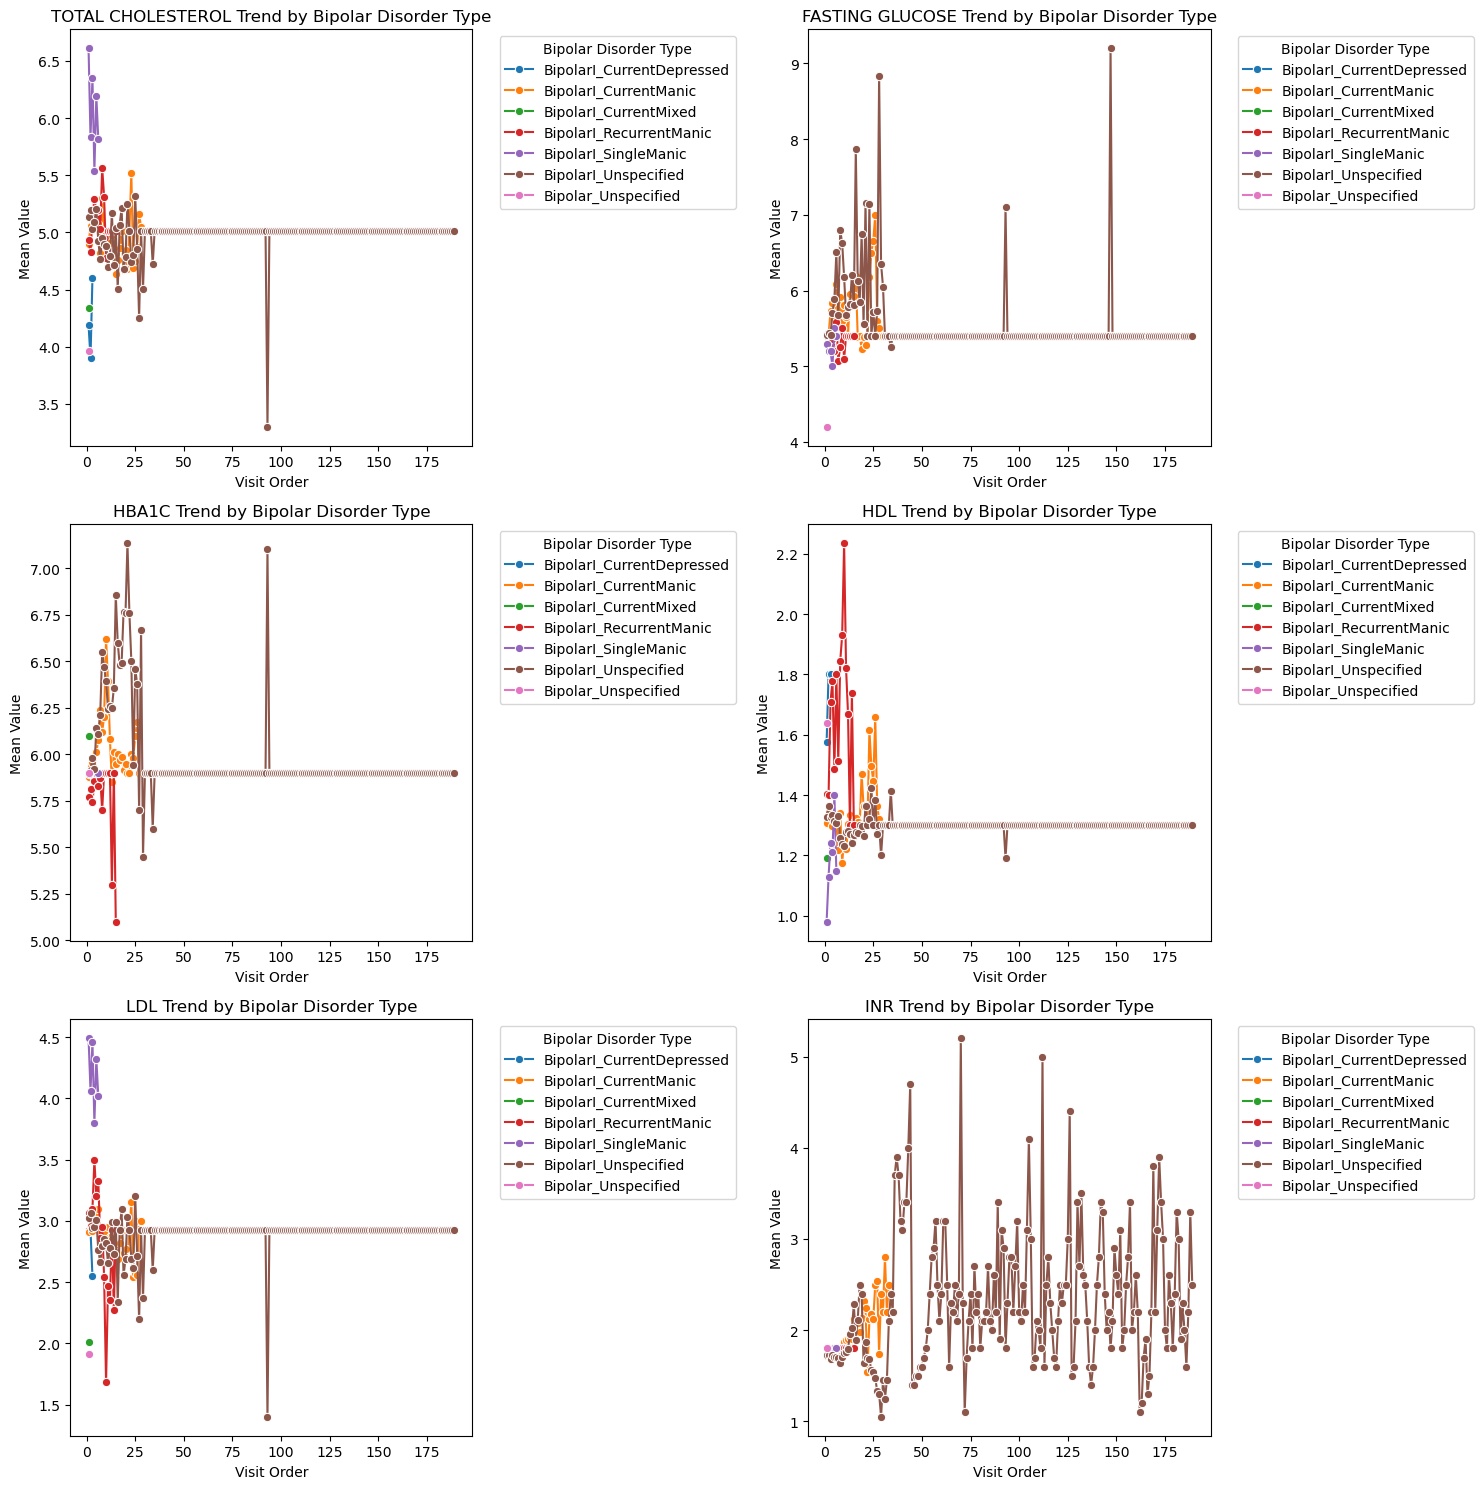

In [10]:
# mapping & encode subtypes of bipolar disorders
bipolar_map = {
    '296.0': 'BipolarI_SingleManic',
    '296.1': 'BipolarI_RecurrentManic',
    '296.4': 'BipolarI_CurrentManic',
    '296.5': 'BipolarI_CurrentDepressed',
    '296.6': 'BipolarI_CurrentMixed',
    '296.7': 'BipolarI_Unspecified',
    '296.8': 'Bipolar_Unspecified'
}

bipolar_order = [
    'BipolarI_SingleManic',
    'BipolarI_RecurrentManic',
    'BipolarI_CurrentManic',
    'BipolarI_CurrentDepressed',
    'BipolarI_CurrentMixed',
    'BipolarI_Unspecified',
    'Bipolar_Unspecified'
]

df = em.map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=bipolar_map,
    ordered_levels=bipolar_order,
    new_label='Bipolar Disorder Type',
    new_factor='Bipolar Disorder Type Factor',
    new_num='Bipolar Disorder Type Num'
)
# visualize grouped trajctory of subtypes of bipolar disorders
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='Bipolar Disorder Type',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)

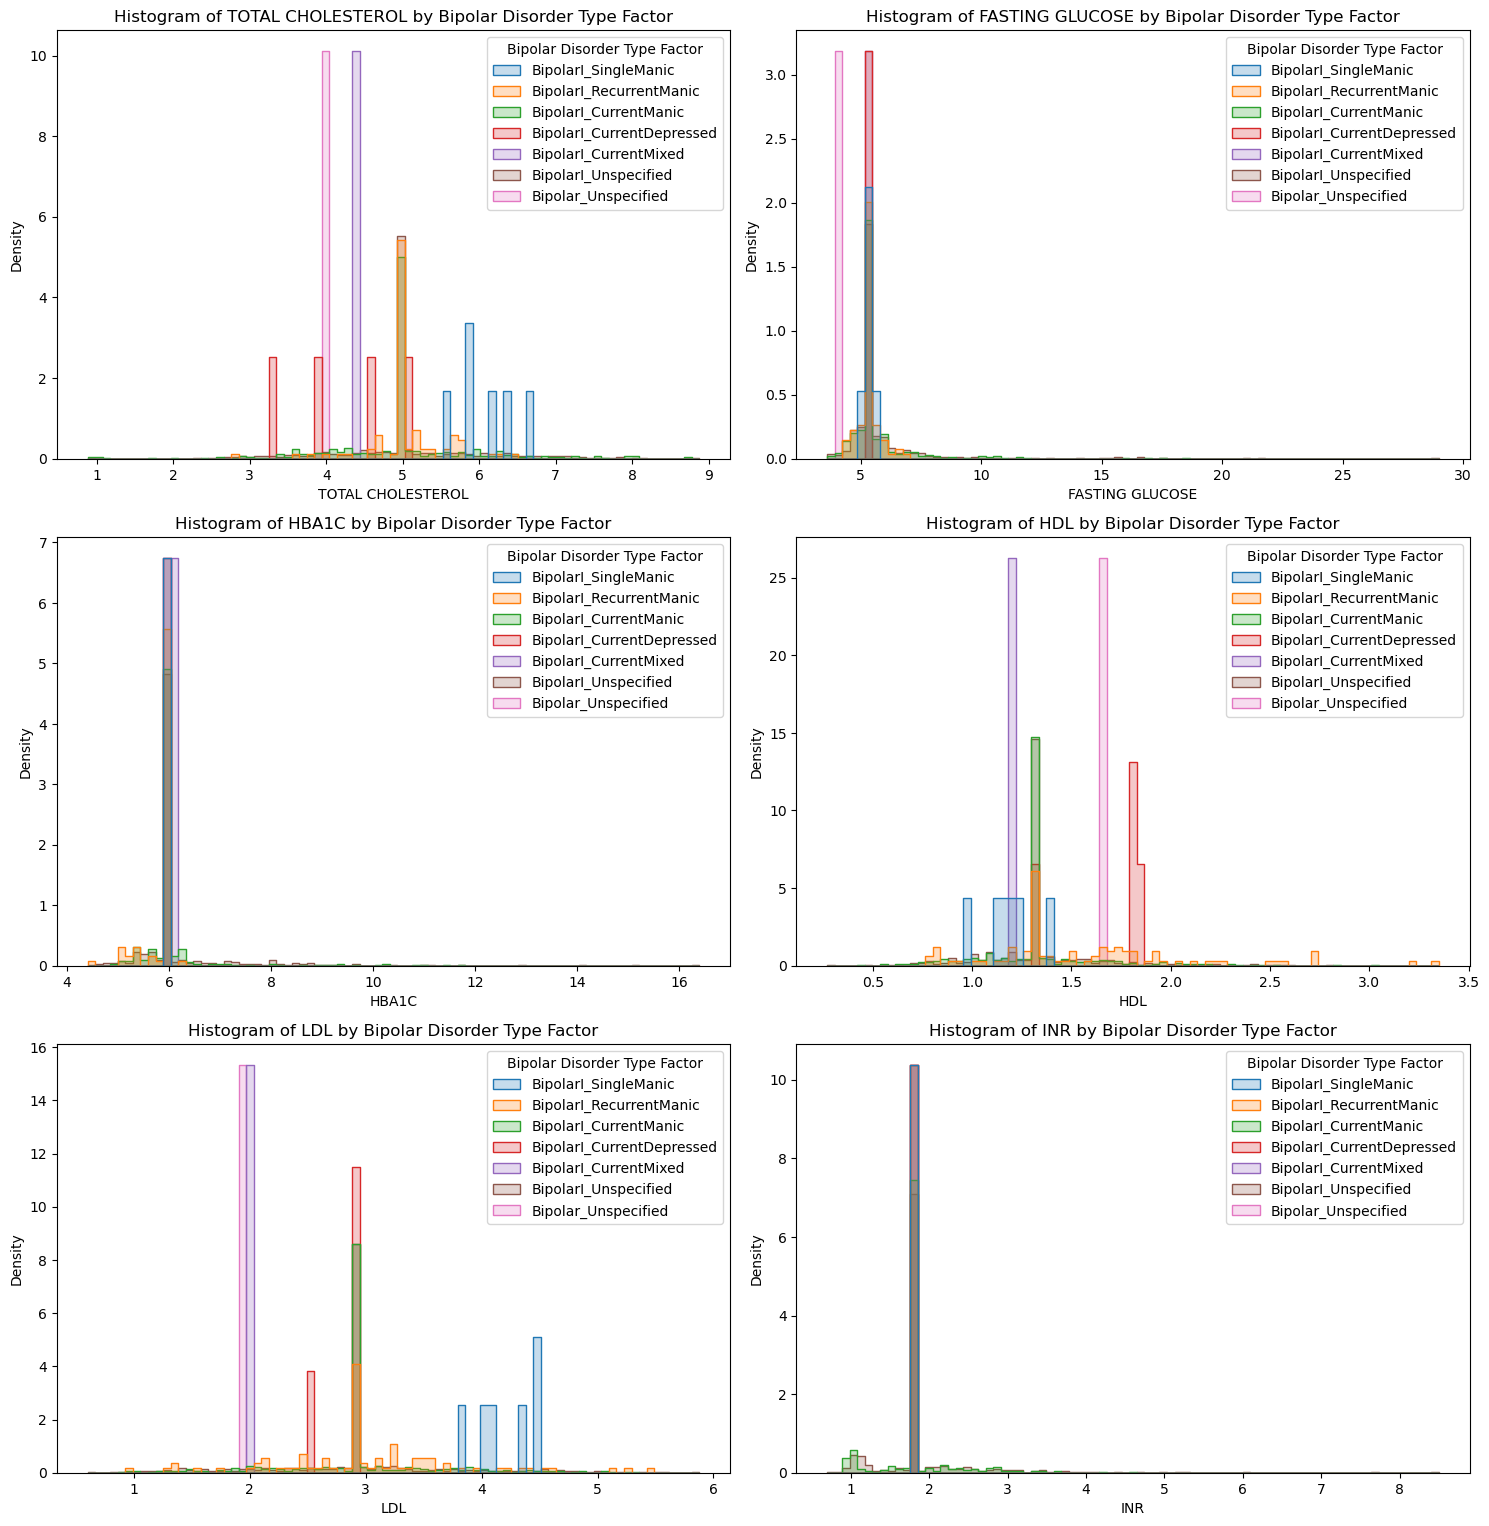

In [11]:
# eda for subtypes of bipolar disorders
em.plot_grouped_histograms(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='Bipolar Disorder Type Factor')

/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby([group_hue, group_x])[var].mean().reset_index()
/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = data.groupby([group_hue, group_x])[var].mean().reset_index()
/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

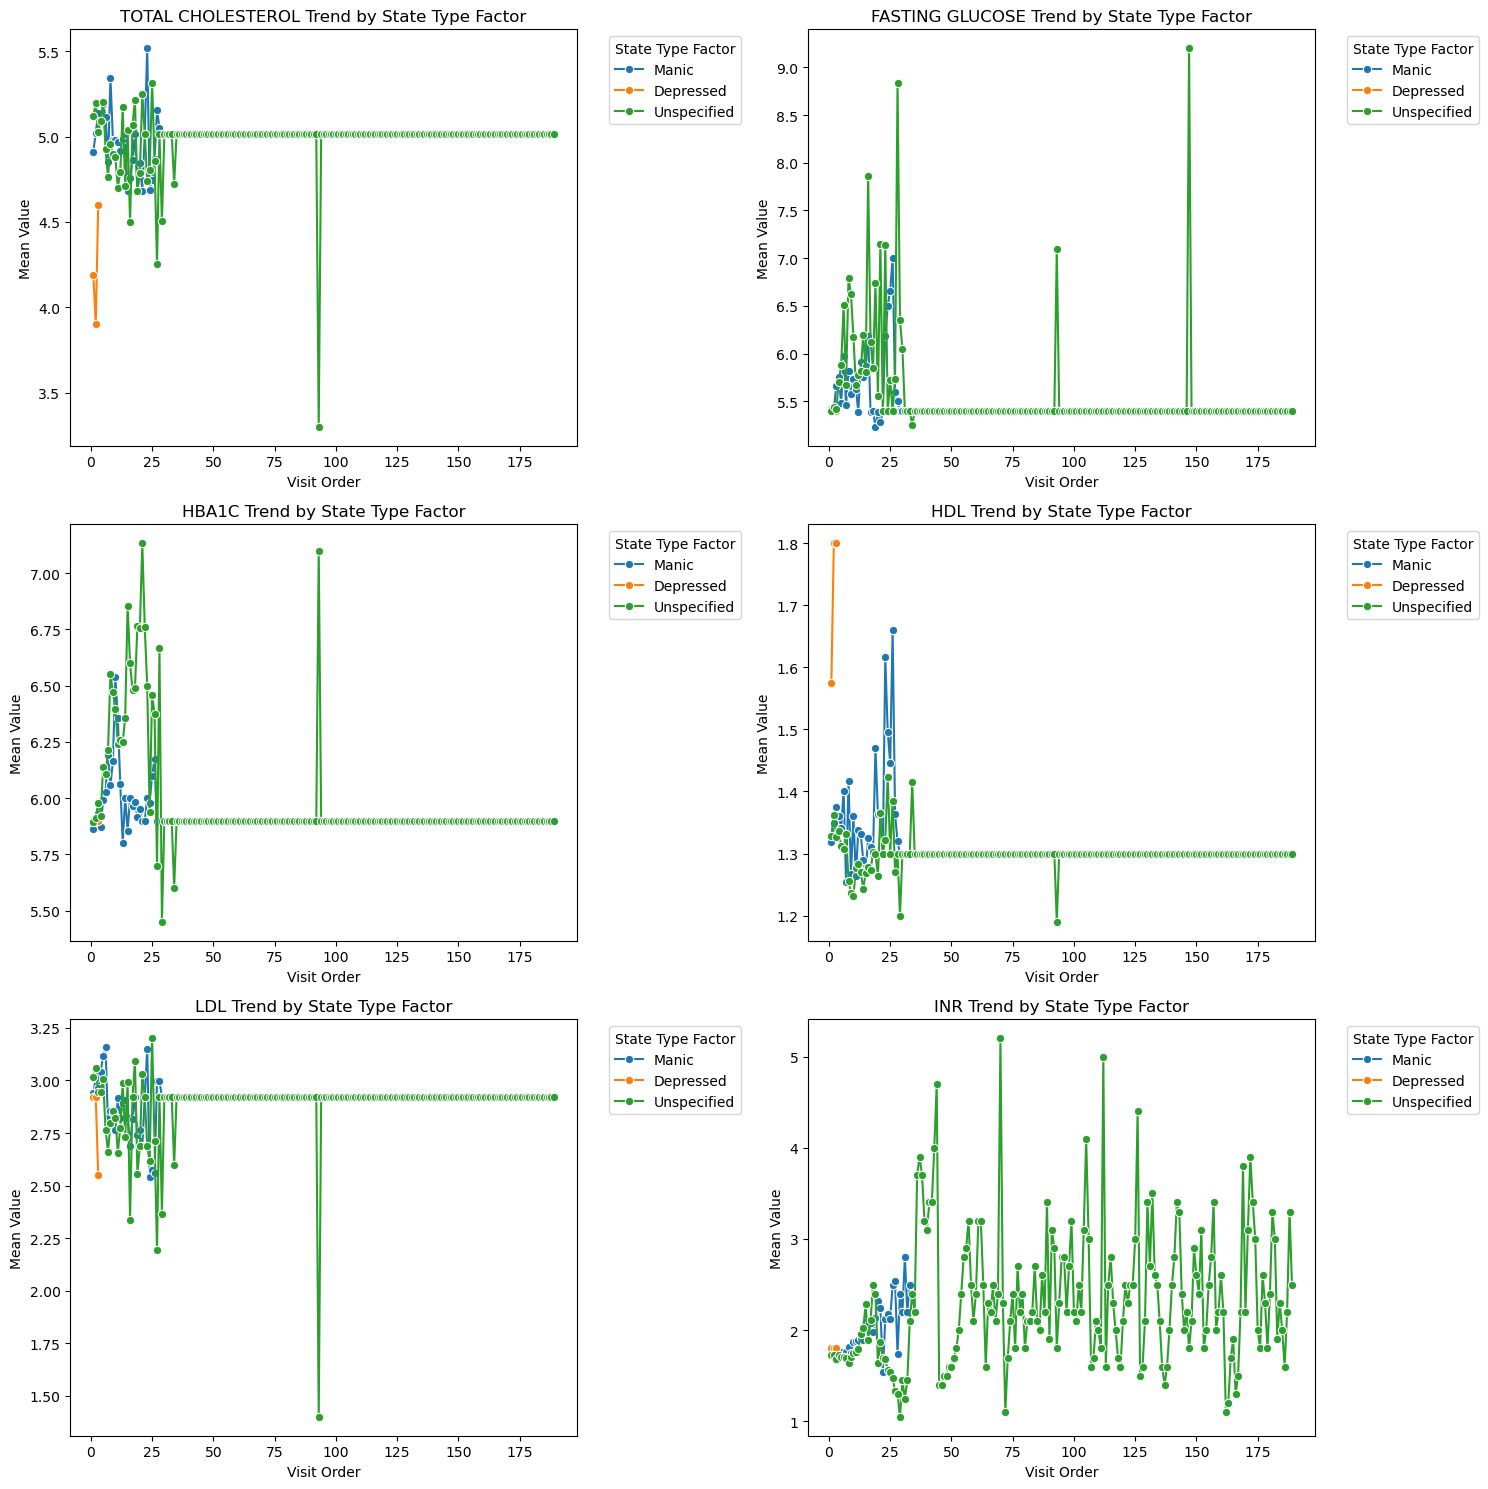

In [12]:
# mapping & encode states of bipolar disorders
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='DiagnosisCode_calc',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)
# visualize states of bipolar disorder
em.plot_grouped_trends(
    data=df,
    variables=['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C', 
            'HDL', 'LDL', 'INR'],
    group_x='VisitOrder',
    group_hue='State Type Factor',
    xlabel='Visit Order',
    ylabel='Mean Value',
    title_prefix='',
)


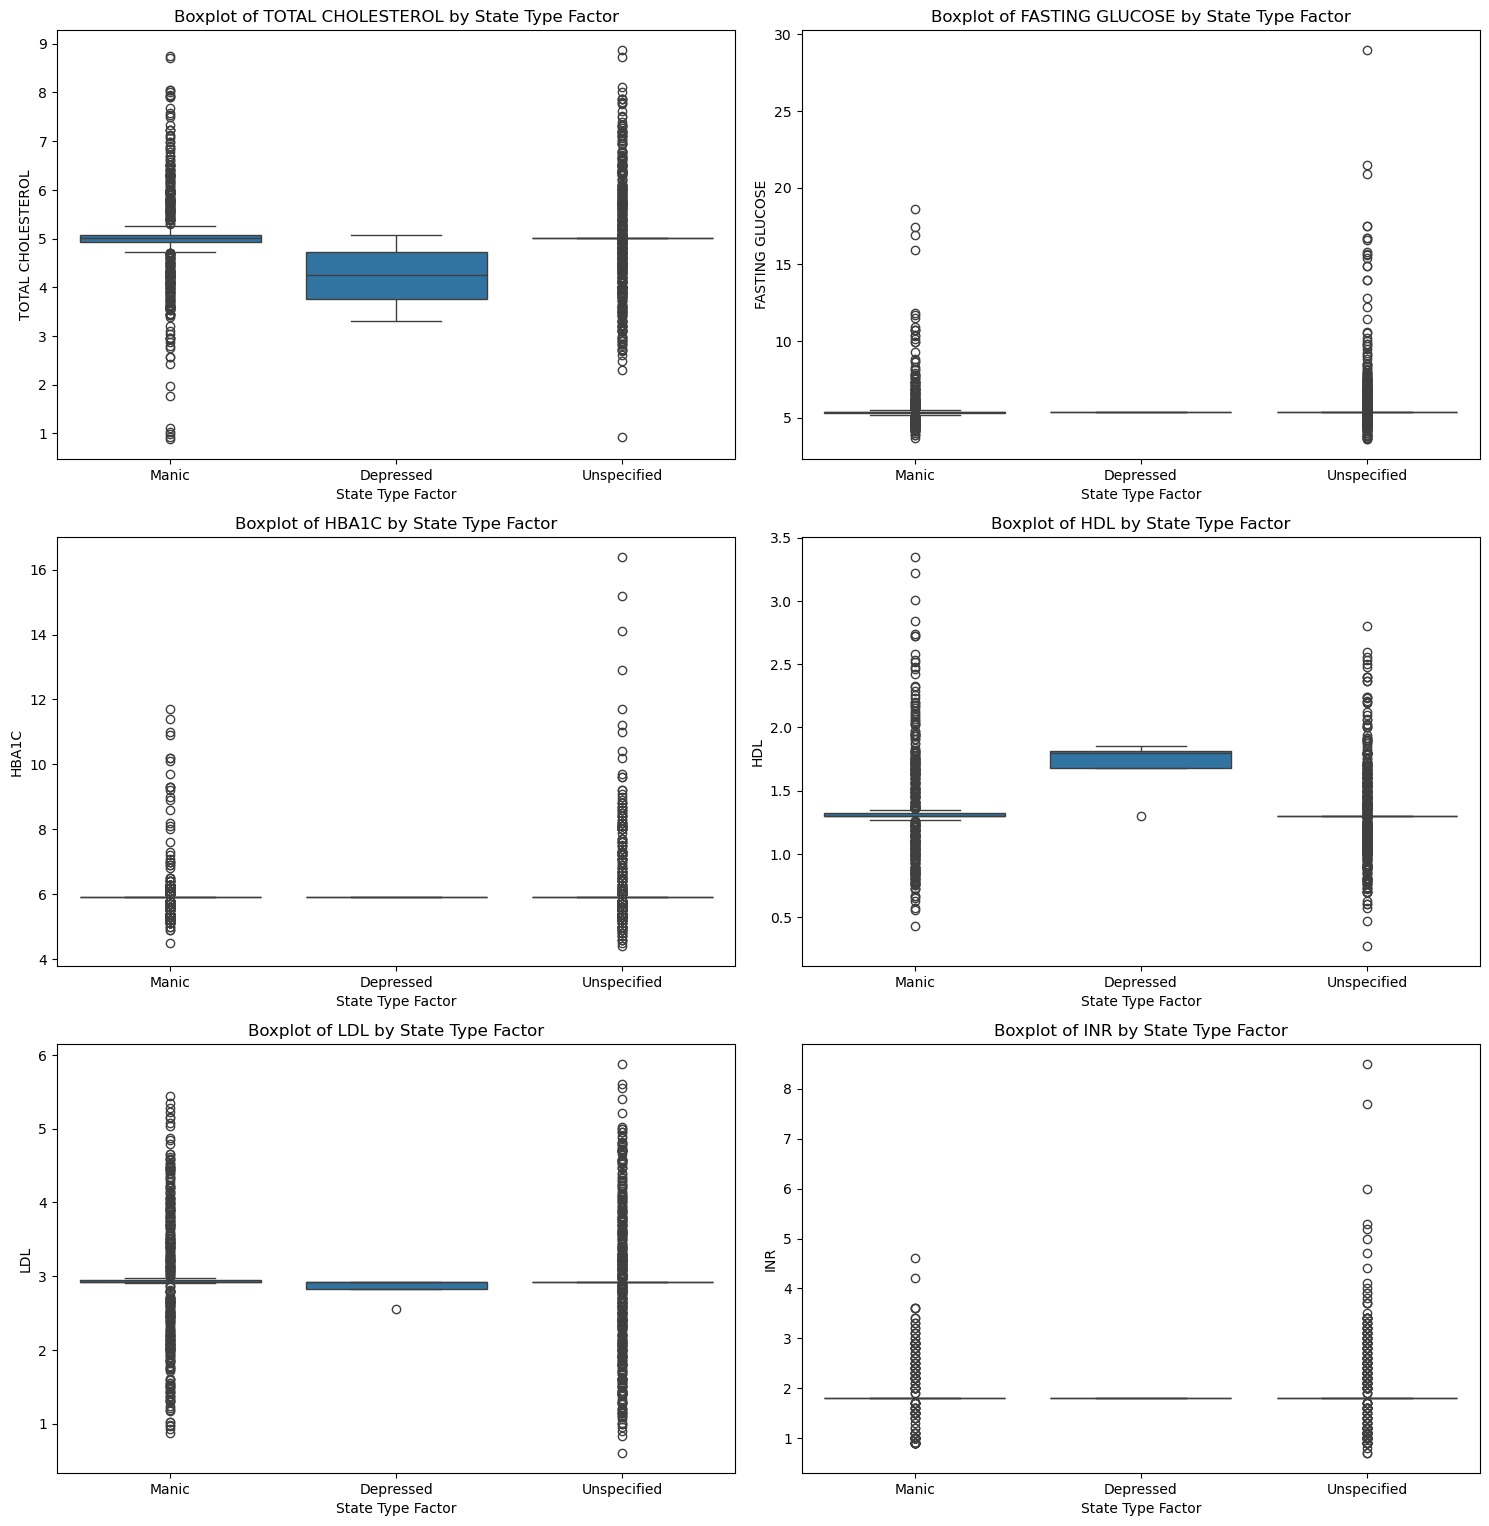

In [13]:
em.plot_grouped_boxplots(df, 
                      variables = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
                      group='State Type Factor')

In [14]:
# Kruskal-Wallis Test to see whether there are significant differences in the variable across multiple State_factor groups.
em.kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='Bipolar Disorder Type Factor')

TOTAL CHOLESTEROL: H=18.041, p=0.0012
FASTING GLUCOSE: H=3.992, p=0.2623
HBA1C: H=7.748, p=0.0208
HDL: H=41.204, p=0.0000
LDL: H=21.505, p=0.0003
INR: H=1.302, p=0.2539


/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_var.groupby(group_col)[var].count()


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,5,18.040769,1.211661e-03
1,FASTING GLUCOSE,4,3.992393,2.622868e-01
2,HBA1C,3,7.748107,2.077400e-02
3,HDL,5,41.204346,2.438301e-08
4,LDL,5,21.505389,2.513631e-04
5,INR,2,1.301704,2.539023e-01


In [15]:
em.kruskal_test(df, 
             variables= ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR'], 
             group_col='State Type Factor')

TOTAL CHOLESTEROL: H=3.043, p=0.2184
FASTING GLUCOSE: H=1.820, p=0.1773
HBA1C: H=1.371, p=0.2417
HDL: H=7.390, p=0.0248
LDL: H=1.751, p=0.4168
INR: H=1.194, p=0.2746


/Users/ervinwu/Documents/CHL8010/CPCSSN-Group-Project/functions/eda_model.py:146: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_var.groupby(group_col)[var].count()


,variable,n_groups,H_stat,p_value
0,TOTAL CHOLESTEROL,3,3.043159,0.218367
1,FASTING GLUCOSE,2,1.820028,0.177310
2,HBA1C,2,1.370632,0.241703
3,HDL,3,7.390497,0.024841
4,LDL,3,1.750528,0.416752
5,INR,2,1.193866,0.274551


Best Parameters from GridSearchCV:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Precision (macro): 0.761

 Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       188
           1       0.86      0.95      0.90       188
           2       0.71      0.65      0.68       189
           5       0.69      0.68      0.68       188

    accuracy                           0.82       753
   macro avg       0.81      0.82      0.81       753
weighted avg       0.81      0.82      0.81       753

Confusion Matrix (Raw Counts):

[[187   0   0   1]
 [  0 178   5   5]
 [  1  14 123  51]
 [  1  14  46 127]]


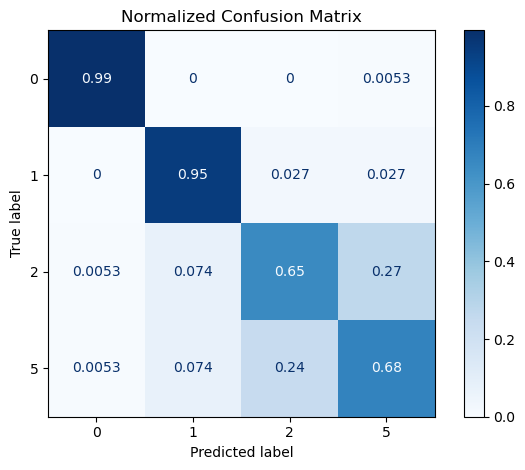

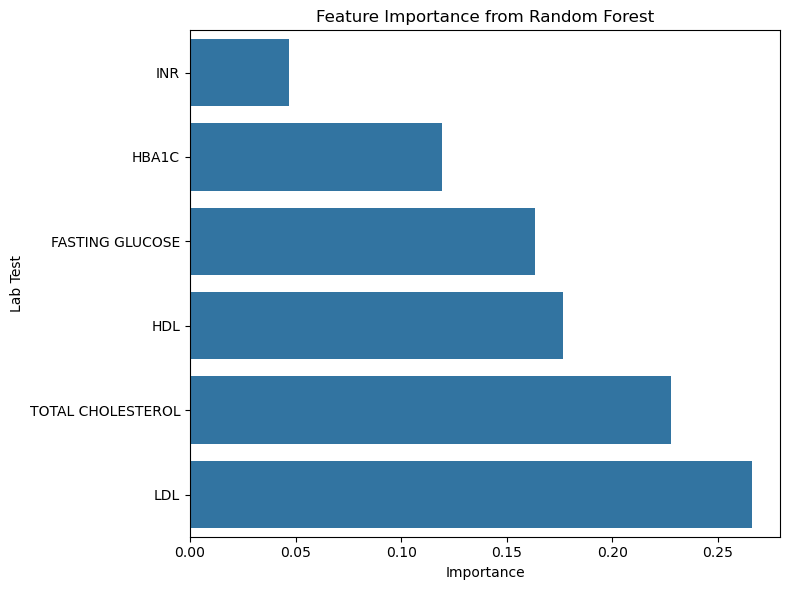


 Cross-Validated Precision (macro): 0.737 ± 0.032


In [16]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# Step 1: Data Preprocessing
# ---------------------------
lab_vars = ['TOTAL CHOLESTEROL', 'FASTING GLUCOSE', 'HBA1C',
            'HDL', 'LDL', 'INR']

df_clean = df.dropna(subset=lab_vars + ['Bipolar Disorder Type Factor'])

# Encode target as numeric codes
df_clean['Bipolar Disorder Type Factor'] = pd.Categorical(df_clean['Bipolar Disorder Type Factor']).codes

# Filter out classes with < 5 samples
class_counts = df_clean['Bipolar Disorder Type Factor'].value_counts()
valid_classes = class_counts[class_counts >= 5].index.tolist()
df_filtered = df_clean[df_clean['Bipolar Disorder Type Factor'].isin(valid_classes)].copy()

X = df_filtered[lab_vars]
y = df_filtered['Bipolar Disorder Type Factor']

# ---------------------------
# Step 2: Scale features
# ---------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# Step 3: Apply SMOTE
# ---------------------------
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# ---------------------------
# Step 4: Train/Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, stratify=y_resampled, test_size=0.2, random_state=42
)

# ---------------------------
# Step 5: Hyperparameter Tuning
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='precision_macro',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters from GridSearchCV:")
print(grid_search.best_params_)
print(f"Best CV Precision (macro): {grid_search.best_score_:.3f}")

# ---------------------------
# Step 6: Final Model Evaluation
# ---------------------------
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix (Raw Counts):\n")
print(confusion_matrix(y_test, y_pred))

# Normalized Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap="Blues", normalize='true')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 7: Feature Importance
# ---------------------------
importances = pd.Series(best_rf.feature_importances_, index=lab_vars).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Lab Test")
plt.tight_layout()
plt.show()

# ---------------------------
# Step 8: Cross-validated Precision
# ---------------------------
cv_scores = cross_val_score(best_rf, X_resampled, y_resampled, cv=5, scoring='precision_macro')
print(f"\n Cross-Validated Precision (macro): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
